# Objective

This project analyzes one year of sales data from a pizza restaurant. 
It explores order-level and item-level data across four linked tables:**Orders**, **Order Details**, **Pizzas**, and **Pizza Types** to understand revenue, demand patterns, and menu performance.

In [1]:
# Import libraries

from pathlib import Path

import numpy as np

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

In [2]:
#Load and Merge Data

data_dir = Path(r"C:\Users\Adorejoy\COHORT 7 NOTEBOOK\pizza_sales")

orders = pd.read_csv(data_dir / "orders.csv")
order_details = pd.read_csv(data_dir / "order_details.csv")
pizzas = pd.read_csv(data_dir / "pizzas.csv")
pizza_types = pd.read_csv(data_dir / "pizza_types.csv", encoding="latin1")

In [3]:
orders.head()

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [4]:
order_details.head()

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [5]:
pizzas.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [6]:
pizza_types.head()

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


In [7]:
shape_summary = pd.DataFrame({
    "dataset": ["orders", "order_details", "pizzas", "pizza_types"],
    "rows": [orders.shape[0], order_details.shape[0], pizzas.shape[0], pizza_types.shape[0]],
    "columns": [orders.shape[1], order_details.shape[1], pizzas.shape[1], pizza_types.shape[1]]
})

shape_summary

,dataset,rows,columns
0,orders,21350,3
1,order_details,48620,4
2,pizzas,96,4
3,pizza_types,32,4


## Merging them into one DataFrame

In [8]:
#Parse date/time
orders['date'] = pd.to_datetime(orders['date'])
orders['time'] = pd.to_datetime(orders['time'], format='%H:%M:%S').dt.time

#Join order_details -> pizzas -> pizza_types -> orders
sales = (order_details
      .merge(pizzas, on='pizza_id', how='left')
      .merge(pizza_types, on='pizza_type_id', how='left')
      .merge(orders, on='order_id', how='left'))

#Derived columns
sales['revenue'] = sales['quantity'] * sales['price']
sales['hour'] = sales['time'].apply(lambda t: t.hour)
sales['day_of_week'] = sales['date'].dt.day_name()
sales['month'] = sales['date'].dt.month_name()
sales['month_num'] = sales['date'].dt.month


sales.head()

,order_details_id,order_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,date,time,revenue,hour,day_of_week,month,month_num
0,1,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",2015-01-01,11:38:36,13.25,11,Thursday,January,1
1,2,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",2015-01-01,11:57:40,16.00,11,Thursday,January,1
2,3,2,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",2015-01-01,11:57:40,18.50,11,Thursday,January,1
3,4,2,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",2015-01-01,11:57:40,20.75,11,Thursday,January,1
4,5,2,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",2015-01-01,11:57:40,16.00,11,Thursday,January,1


In [9]:
sales.shape

(48620, 17)

In [10]:
#overview of the columns

sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  48620 non-null  int64         
 1   order_id          48620 non-null  int64         
 2   pizza_id          48620 non-null  object        
 3   quantity          48620 non-null  int64         
 4   pizza_type_id     48620 non-null  object        
 5   size              48620 non-null  object        
 6   price             48620 non-null  float64       
 7   name              48620 non-null  object        
 8   category          48620 non-null  object        
 9   ingredients       48620 non-null  object        
 10  date              48620 non-null  datetime64[ns]
 11  time              48620 non-null  object        
 12  revenue           48620 non-null  float64       
 13  hour              48620 non-null  int64         
 14  day_of_week       4862

In [11]:
#checking for null values

sales.isna().sum()

order_details_id    0
order_id            0
pizza_id            0
quantity            0
pizza_type_id       0
size                0
price               0
name                0
category            0
ingredients         0
date                0
time                0
revenue             0
hour                0
day_of_week         0
month               0
month_num           0
dtype: int64

## Total revenue/sales

In [12]:
total_revenue = sales["revenue"].sum()

print(f"Total Revenue/Sales: ${total_revenue:,.2f}")

Total Revenue/Sales: $817,860.05


**Insights**

- The restaurant generated a total revenue of **$817,860.05** during the year.

## Total Quantity Sold

In [13]:
total_quantity_sold = sales["quantity"].sum()

print(f"Total Quantity Sold: {total_quantity_sold:,}")

Total Quantity Sold: 49,574


## Total Orders

In [14]:
total_orders = sales["order_id"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 21,350


## Number of Pizza Types Sold

In [15]:
pizza_types_sold = sales["pizza_type_id"].nunique()

print(f"Pizza Types Sold: {pizza_types_sold}")

Pizza Types Sold: 32


## Average Pizza Price

In [16]:
average_price = pizzas["price"].mean()

print(f"Average Price of Pizzas: ${average_price:,.2f}")

Average Price of Pizzas: $16.44


## Peak Hours of Sales

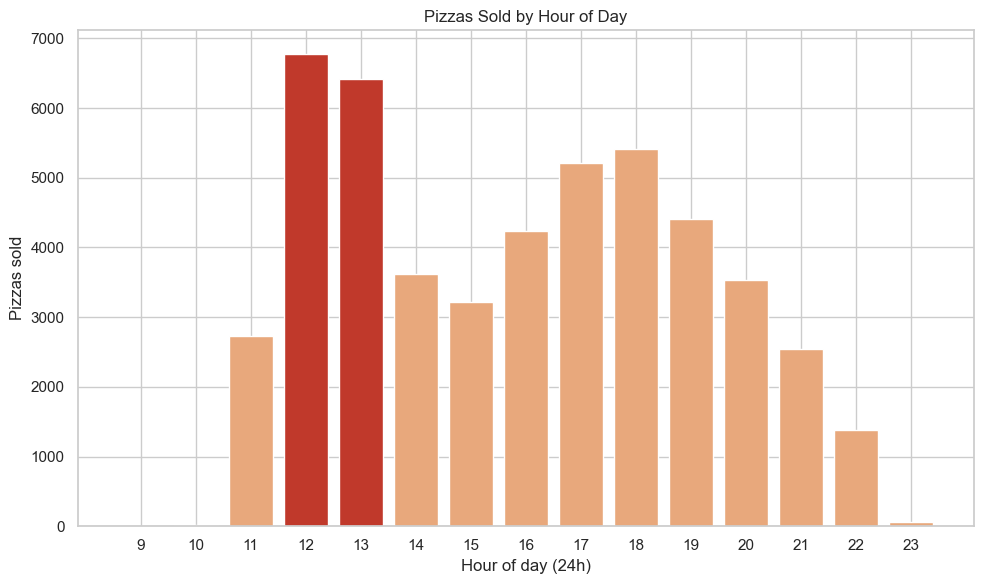

hour
12    6776
13    6413
18    5417
17    5211
19    4406
Name: quantity, dtype: int64

In [17]:
peak_sales_hours = sales.groupby("hour")["quantity"].sum().sort_index()

# Plot peak hours
plt.figure(figsize=(10, 6))
colors = ['#c0392b' if h in peak_sales_hours.sort_values(ascending=False).head(2).index 
          else '#e8a87c' for h in peak_sales_hours.index]
plt.bar(peak_sales_hours.index, peak_sales_hours.values, color=colors)
plt.xlabel("Hour of day (24h)")
plt.ylabel("Pizzas sold")
plt.title("Pizzas Sold by Hour of Day")
plt.xticks(range(9, 24))
plt.tight_layout()
plt.savefig(r"C:\Users\Adorejoy\COHORT 7 NOTEBOOK\pizza_sales\peak_sales_hours.png", dpi=300, bbox_inches="tight")
plt.show()

peak_sales_hours.sort_values(ascending=False).head(5)

**Insights**
- Sales show two clear peaks: a **lunch rush around 12:00–13:00** and a **dinner rush around 17:00–19:00**, with 12:00 being the single busiest hour.
- Very little happens before 10:00 or after 22:00. Staffing and prep should be concentrated in the two peak windows rather than spread evenly across the day.

## Sales by Day of Week

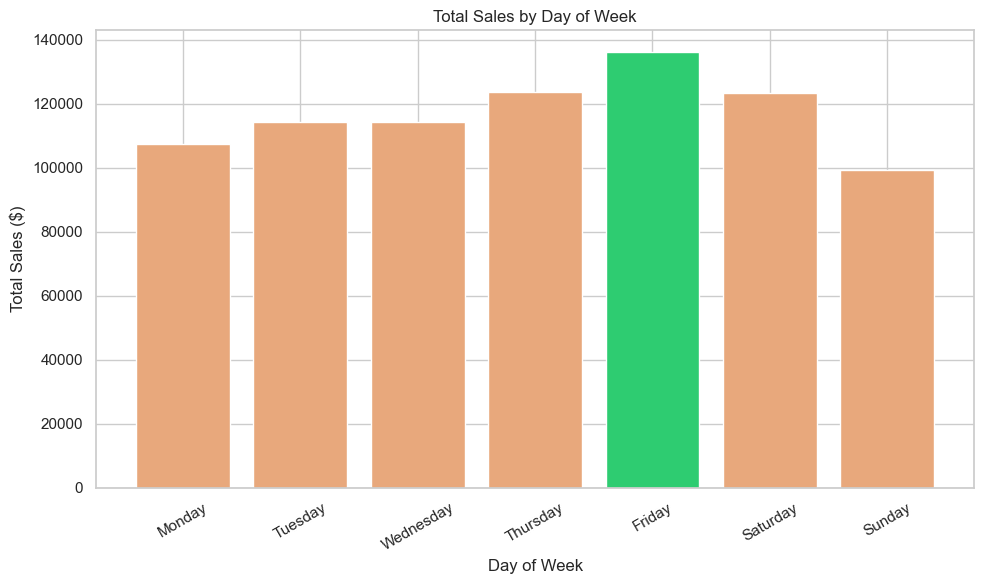

day_of_week
Friday      136,073.90
Thursday    123,528.50
Saturday    123,182.40
Wednesday   114,408.40
Tuesday     114,133.80
Monday      107,329.55
Sunday       99,203.50
Name: revenue, dtype: float64

In [18]:
day_of_week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales = sales.groupby('day_of_week')['revenue'].sum().reindex(day_of_week)

# Plot sales by day
plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if day == day_sales.idxmax() else '#e8a87c' for day in day_sales.index]
plt.bar(day_sales.index, day_sales.values, color = colors)
plt.ylabel('Total Sales ($)')
plt.xlabel("Day of Week")
plt.title('Total Sales by Day of Week')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(r"C:\Users\Adorejoy\COHORT 7 NOTEBOOK\pizza_sales\sales_by_day.png", dpi=300, bbox_inches="tight")
plt.show()

day_sales.sort_values(ascending=False)

**Insights**
- **Friday is the best-selling day** (\$136,073.90), followed by Thursday and Saturday, consistent with people treating themselves at the end of the work week and on weekends.
- **Sunday is the slowest day** (\$99,203.50), noticeably behind every other day. A Sunday-specific promotion (e.g. a discount or bundle) could help even out weekly demand.

## Top 5 bestselling pizzas

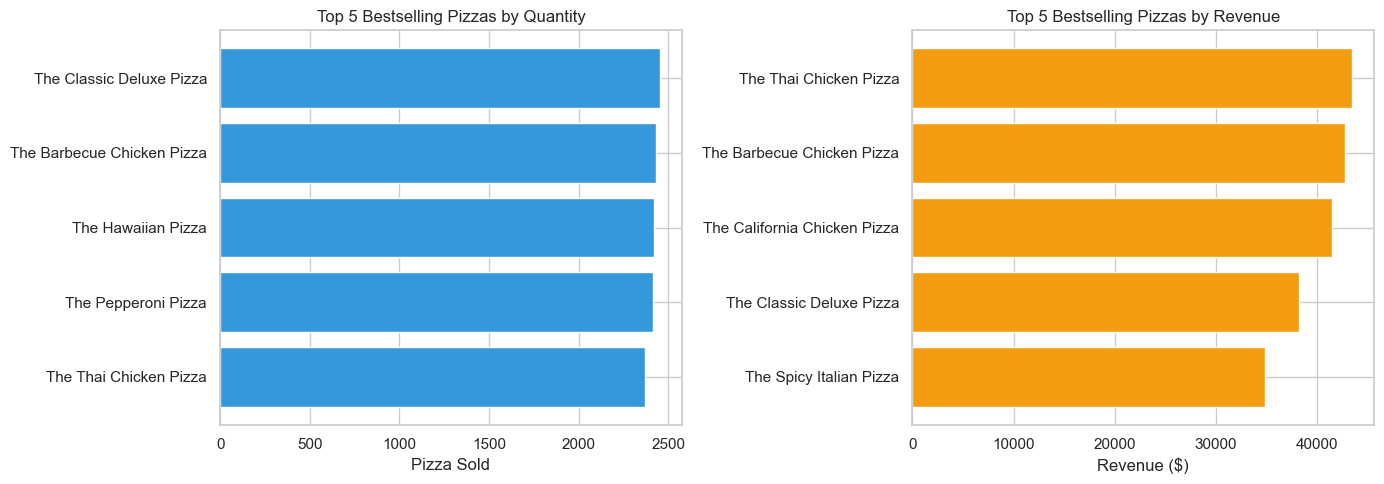

Top 5 Bestselling Pizzas by Quantity:
name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64

Top 5 Bestselling Pizzas by Revenue
name
The Thai Chicken Pizza         43,434.25
The Barbecue Chicken Pizza     42,768.00
The California Chicken Pizza   41,409.50
The Classic Deluxe Pizza       38,180.50
The Spicy Italian Pizza        34,831.25
Name: revenue, dtype: float64


In [19]:
top5_quantity = (sales.groupby('name')['quantity'].sum().sort_values(ascending=False).head(5))
top5_revenue = sales.groupby('name')['revenue'].sum().sort_values(ascending=False).head(5)

#plot bestselling pizzas
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.barh(top5_quantity.index[::-1], top5_quantity.values[::-1], color="#3498db")
plt.title("Top 5 Bestselling Pizzas by Quantity")
plt.xlabel("Pizza Sold")

plt.subplot(1, 2, 2)
plt.barh(top5_revenue.index[::-1], top5_revenue.values[::-1], color="#f39c12")
plt.title("Top 5 Bestselling Pizzas by Revenue")
plt.xlabel("Revenue ($)")

plt.tight_layout()
plt.savefig(r"C:\Users\Adorejoy\COHORT 7 NOTEBOOK\pizza_sales\top5_bestselling_pizzas.png", dpi=300, bbox_inches="tight")
plt.show()


print("Top 5 Bestselling Pizzas by Quantity:")
print(top5_quantity)

print("\nTop 5 Bestselling Pizzas by Revenue")
print(top5_revenue)

**Insights**
- By **quantity**, the top sellers are The Classic Deluxe, The Barbecue Chicken, The Hawaiian, The Pepperoni, and The Thai Chicken a mix of classic and chicken-based pizzas.
- By **revenue**, the ranking shifts: The Thai Chicken Pizza and The Barbecue Chicken Pizza lead, because chicken pizzas are priced higher than classics like Hawaiian or Pepperoni. 
  The Classic Deluxe sells the most units but ranks only 4th in revenue, a reminder that "most popular" and "most profitable" aren't always the same pizza.

## Monthly sales trend

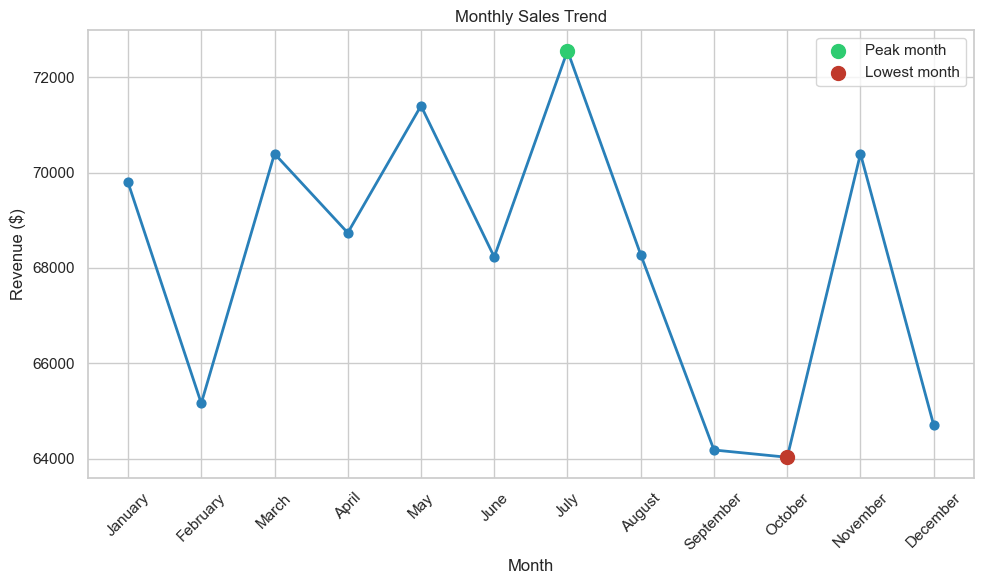

month
January     69,793.30
February    65,159.60
March       70,397.10
April       68,736.80
May         71,402.75
June        68,230.20
July        72,557.90
August      68,278.25
September   64,180.05
October     64,027.60
November    70,395.35
December    64,701.15
Name: revenue, dtype: float64

In [20]:
monthly_sales = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly_revenue = sales.groupby('month')['revenue'].sum().reindex(monthly_sales)

# Plot sales by month
plt.figure(figsize=(10, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, color='#2980b9', linewidth=2, zorder=1)

# Highlight best and worst month
best_month = monthly_revenue.idxmax()
worst_month = monthly_revenue.idxmin()
plt.scatter(best_month, monthly_revenue[best_month], color='#2ecc71', s=100, zorder=2, label='Peak month')
plt.scatter(worst_month, monthly_revenue[worst_month], color='#c0392b', s=100, zorder=2, label='Lowest month')

# Regular markers for the rest
other_months = [m for m in monthly_revenue.index if m not in (best_month, worst_month)]
plt.scatter(other_months, monthly_revenue[other_months], color='#2980b9', s=40, zorder=2)

plt.ylabel('Revenue ($)')
plt.xlabel("Month")
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\Adorejoy\COHORT 7 NOTEBOOK\pizza_sales\monthly_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()
plt.show()

# Format with comma thousands separator and 2 decimal places
pd.set_option('display.float_format', '{:,.2f}'.format)
monthly_revenue

**Insights**
- Revenue is fairly stable across the year, generally sitting between **\$64,000 and \$72,500 per month** there's no single dominant seasonal spike.
- **July** is the strongest month (\$72,557.90), and **May, January, March, and November** are also above average, these roughly track US holidays/summer occasions (July 4th, back-to-school-adjacent spring months).
- **September, October, and December are the softest months.** December is a bit surprising given the holiday season is usually strong for food businesses, that dip could be worth digging into further (e.g. holiday closures, competition from home-cooked meals, or fewer takeout occasions around family gatherings). **February's** dip (the shortest month) may partly reflect fewer calendar days rather than weaker daily demand.</br>
Overall the trend is mild and cyclical rather than strongly seasonal, this business doesn't appear to depend heavily on any one time of year.

## Pizza Types That Are Underperforming

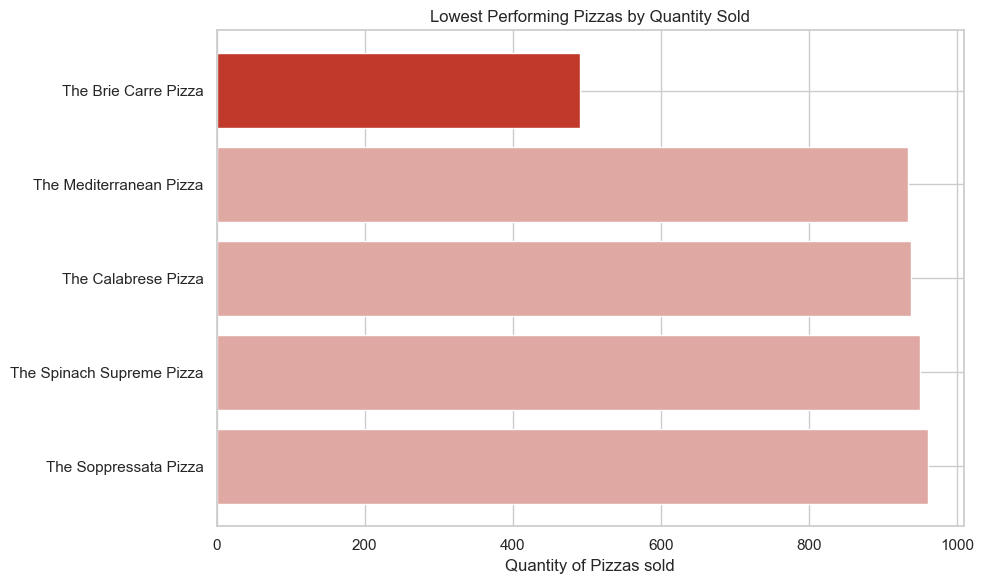

name
The Brie Carre Pizza         490
The Mediterranean Pizza      934
The Calabrese Pizza          937
The Spinach Supreme Pizza    950
The Soppressata Pizza        961
Name: quantity, dtype: int64

In [21]:
pizza_performance = sales.groupby('name')['quantity'].sum().sort_values()
low_performers = pizza_performance.head(5)

# Highlight the single weakest pizza in a stronger red; the rest in a muted red
colors = ['#c0392b' if name == low_performers.idxmin() else '#e0a8a2' 
          for name in low_performers.index[::-1]]

plt.figure(figsize=(10, 6))
plt.barh(low_performers.index[::-1], low_performers.values[::-1], color=colors)
plt.xlabel('Quantity of Pizzas sold')
plt.title('Lowest Performing Pizzas by Quantity Sold')
plt.ylabel("")
plt.tight_layout()
plt.savefig(r"C:\Users\Adorejoy\COHORT 7 NOTEBOOK\pizza_sales\low_performing_pizzas.png", dpi=300, bbox_inches="tight")
plt.show()

low_performers

**Insights**
- **The Brie Carre Pizza** is by far the weakest performer, selling only **490** units over the whole year, roughly a fifth of the top sellers. The Mediterranean, Calabrese, Spinach Supreme, and Soppressata pizzas also trail the pack.
- These are mostly specialty/gourmet pizzas with less mainstream ingredients (brie, soppressata, calabrese salami), which likely explains the lower demand compared to familiar classics like Pepperoni or Hawaiian.
- Worth testing: a menu redesign that features these less-often, a limited-time promotion to see if awareness (not taste) is the bottleneck, or replacing the very weakest item (Brie Carre) with a new pizza.

##  Order size distribution

How many pizzas do people order at once?

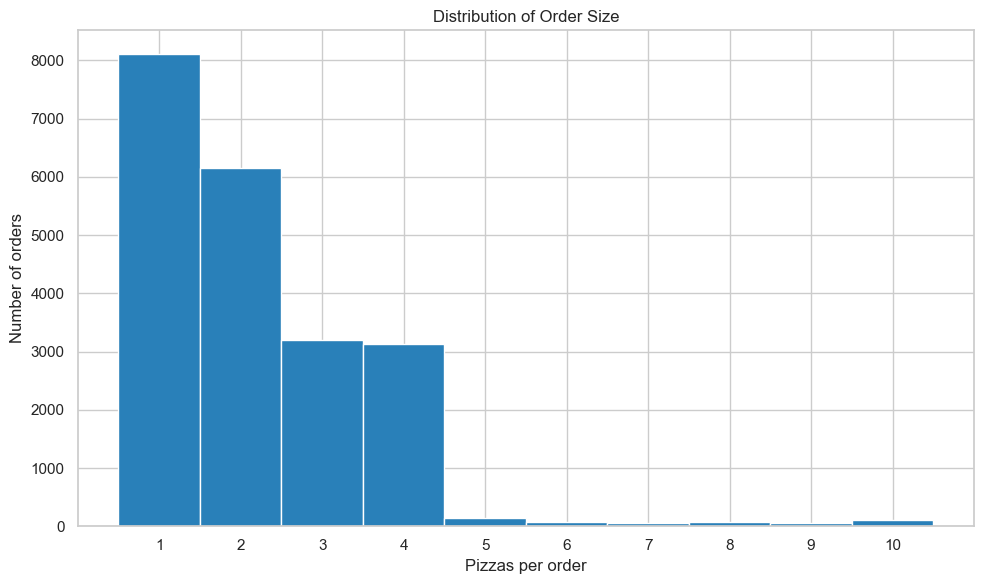

quantity
1     8111
2     6152
3     3207
4     3122
5      145
6       80
7       61
8       67
9       64
10      56
Name: count, dtype: int64

In [22]:
order_size = sales.groupby('order_id')['quantity'].sum()

plt.figure(figsize=(10, 6))
plt.hist(order_size, bins=range(1, 12), color='#2980b9', edgecolor='white', align='left')
plt.xlabel('Pizzas per order')
plt.ylabel('Number of orders')
plt.title('Distribution of Order Size')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.savefig(r"C:\Users\Adorejoy\COHORT 7 NOTEBOOK\pizza_sales\order_size_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

order_size.value_counts().sort_index().head(10)

**Insight**
- The vast majority of orders are small **38% of orders are for just **1 pizza**, and 29% for 2 pizzas**. Orders of 5+ pizzas are rare (under 2% combined).
- This matters for your earlier **"average items per order = 2.32" stat**, that average is being pulled up by a small number of large orders (likely group/party orders), while the typical customer orders 1–2 pizzas. </br> If you're thinking about upsell strategy, a "add a second pizza" prompt at checkout would target the biggest single segment (the 1-pizza orders).

## Price vs. popularity

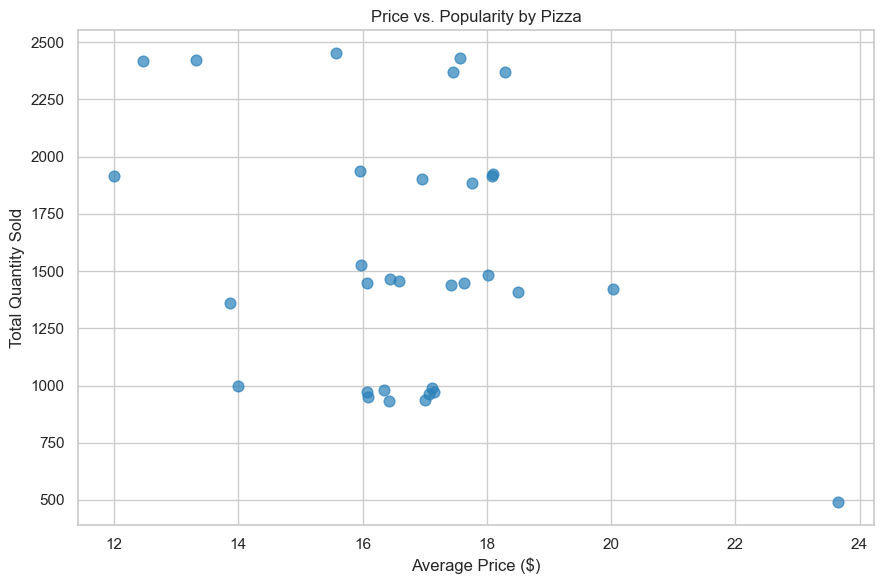

Correlation between price and quantity sold: -0.31


In [23]:
pizza_summary = sales.groupby('name').agg(avg_price=('price', 'mean'), quantity=('quantity', 'sum'))

plt.figure(figsize=(9, 6))
plt.scatter(pizza_summary['avg_price'], pizza_summary['quantity'], color='#2980b9', s=60, alpha=0.7)
plt.xlabel('Average Price ($)')
plt.ylabel('Total Quantity Sold')
plt.title('Price vs. Popularity by Pizza')
plt.tight_layout()
plt.savefig(r"C:\Users\Adorejoy\COHORT 7 NOTEBOOK\pizza_sales\price_vs_popularity.png", dpi=300, bbox_inches="tight")
plt.show()

print("Correlation between price and quantity sold:", round(pizza_summary['avg_price'].corr(pizza_summary['quantity']), 2))

**Insight**

- Price and quantity sold show a weak negative correlation (**-0.31**) — pricier pizzas trend slightly lower in sales, but the relationship is loose, not strong. This suggests flavor/ingredients matter more than price in driving popularity, and underperforming pizzas shouldn't be assumed to be struggling on price alone.

## Category & Size Performance: Revenue vs. Quantity

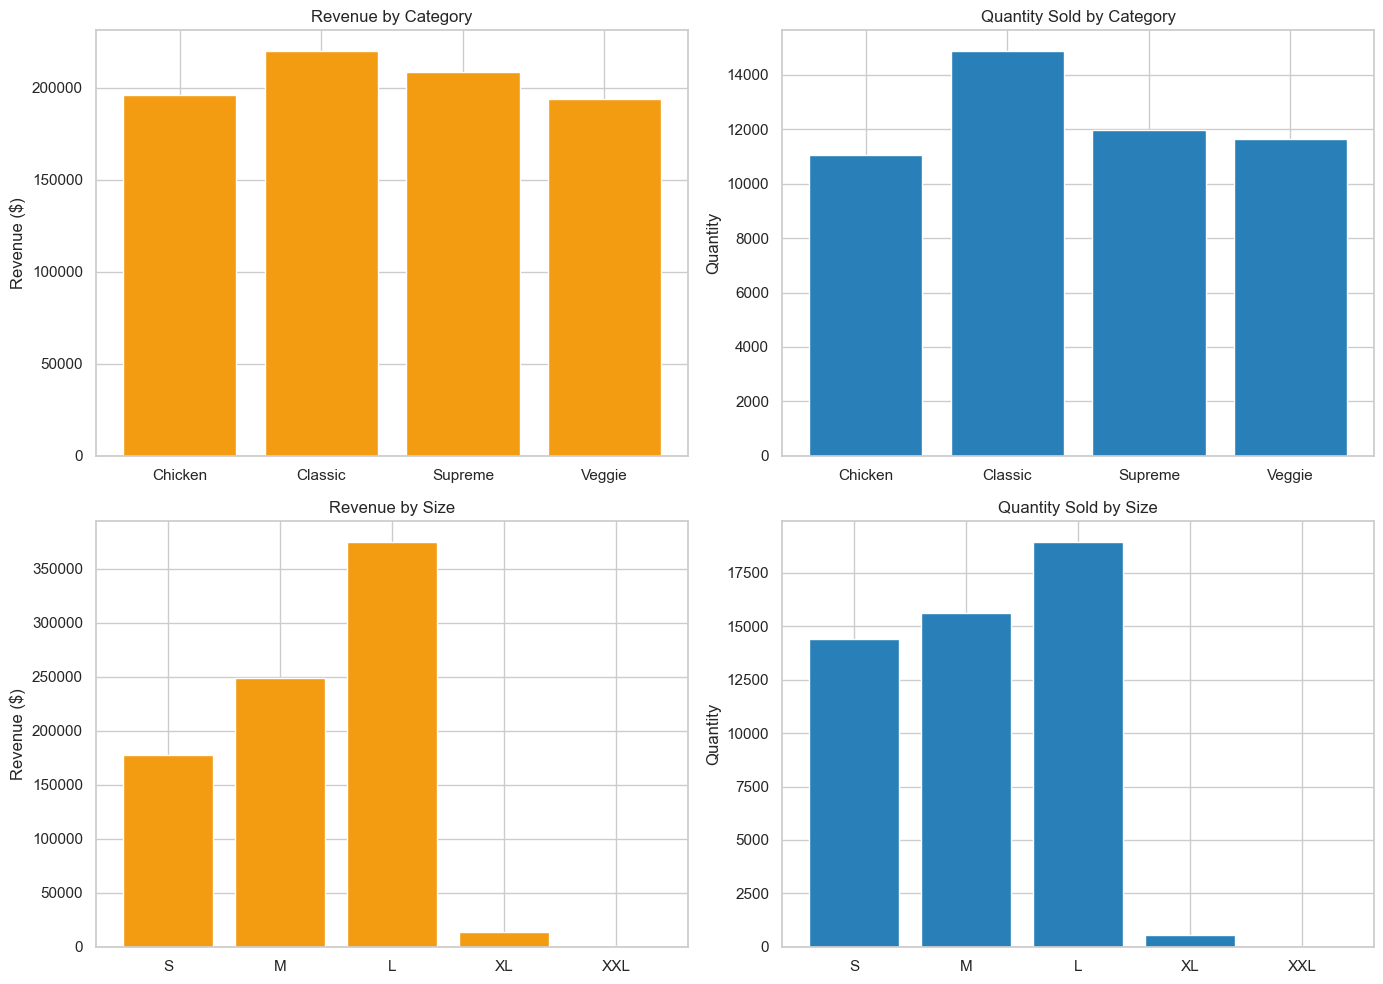

,category,revenue,quantity
0,Chicken,"195,919.50",11050
1,Classic,"220,053.10",14888
2,Supreme,"208,197.00",11987
3,Veggie,"193,690.45",11649


,size,revenue,quantity
0,S,"178,076.50",14403
1,M,"249,382.25",15635
2,L,"375,318.70",18956
3,XL,"14,076.00",552
4,XXL,"1,006.60",28


In [24]:
category_sales = (sales.groupby("category", as_index=False)
    .agg(revenue=("revenue","sum"), quantity=("quantity","sum")))
size_sales = (sales.groupby("size", as_index=False)
    .agg(revenue=("revenue","sum"), quantity=("quantity","sum"))
    .set_index("size").reindex(["S","M","L","XL","XXL"]).dropna().reset_index())

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.bar(category_sales["category"], category_sales["revenue"], color="#f39c12")
plt.title("Revenue by Category")
plt.ylabel("Revenue ($)")

plt.subplot(2, 2, 2)
plt.bar(category_sales["category"], category_sales["quantity"], color="#2980b9")
plt.title("Quantity Sold by Category")
plt.ylabel("Quantity")

plt.subplot(2, 2, 3)
plt.bar(size_sales["size"], size_sales["revenue"], color="#f39c12")
plt.title("Revenue by Size")
plt.ylabel("Revenue ($)")

plt.subplot(2, 2, 4)
plt.bar(size_sales["size"], size_sales["quantity"], color="#2980b9")
plt.title("Quantity Sold by Size")
plt.ylabel("Quantity")

plt.tight_layout()
plt.savefig(r"C:\Users\Adorejoy\COHORT 7 NOTEBOOK\pizza_sales\category_size_full.png", dpi=300, bbox_inches="tight")
plt.show()

display(category_sales)
display(size_sales)

**Insights**

- Classic leads category revenue ($220,053.10) and quantity sold (14,888), but the gap over Chicken is smaller in revenue than it looks — Chicken generates $195,919.50 from just 11,050 pizzas, meaning each Chicken pizza sold is worth noticeably more on average than a Classic one. With only 6 recipes to Classic's 8, Chicken is the most revenue-efficient category per pizza type, while Veggie (9 recipes) produces the least revenue per recipe of any category.
- Large is the dominant size on both metrics it leads quantity (18,956 units) and revenue ($375,318.70, roughly 46% of total revenue), confirming that Large's revenue strength comes from genuine popularity, not just a higher price tag.
- XL and XXL are priced at a premium ($25.50 and $35.95 average) but sell in negligible volume (552 and 28 units respectively) together they make up under 2% of total revenue despite being the highest-priced sizes on the menu. This isn't a pricing problem, since S→M→L→XL→XXL scales predictably; it's a demand problem, and these sizes may not be worth the added inventory complexity unless they're tied to a specific standout recipe.
  
Overall, category performance is about recipe efficiency (Chicken squeezes more revenue from fewer recipes) while size performance is about volume concentration (nearly half of all revenue rides on a single size). These point to two different levers: menu expansion should lean toward Chicken-style recipes, while inventory and pricing strategy should be built around Large as the default, with XL/XXL treated as a low-priority long tail.

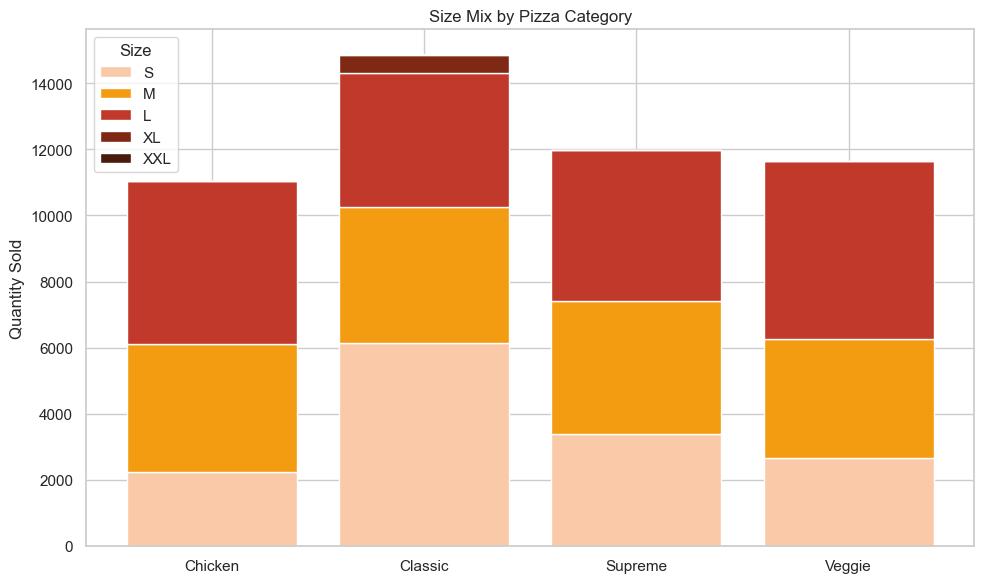

size,S,M,L,XL,XXL
category,,,,,
Chicken,"2,224.00","3,894.00","4,932.00",0.00,0.00
Classic,"6,139.00","4,112.00","4,057.00",552.00,28.00
Supreme,"3,377.00","4,046.00","4,564.00",0.00,0.00
Veggie,"2,663.00","3,583.00","5,403.00",0.00,0.00


In [25]:
size_by_category = sales.groupby(['category', 'size'])['quantity'].sum().unstack().reindex(columns=['S','M','L','XL','XXL']).fillna(0)

plt.figure(figsize=(10, 6))
bottom = None
colors = {'S':'#f9c9a8','M':'#f39c12','L':'#c0392b','XL':'#7f2914','XXL':'#4a1a0c'}
for size in ['S','M','L','XL','XXL']:
    vals = size_by_category[size]
    plt.bar(size_by_category.index, vals, bottom=bottom, label=size, color=colors[size])
    bottom = vals if bottom is None else bottom + vals

plt.ylabel('Quantity Sold')
plt.title('Size Mix by Pizza Category')
plt.legend(title='Size')
plt.tight_layout()
plt.savefig(r"C:\Users\Adorejoy\COHORT 7 NOTEBOOK\pizza_sales\size_mix_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

size_by_category

**Insight**
- **Classic is the only category sold in XL/XXL** at all (580 units combined) every other category (Chicken, Supreme, Veggie) is offered only in S/M/L. Within Classic, **Small is actually the most-ordered size** (6,139 units), unlike every other category where Large dominates. This is a genuine menu-structure finding, not just a sales pattern, it's worth checking whether Classic's heavy Small-size volume comes from a specific popular item (like a personal-size Margherita) that's skewing that category's numbers.

## Top Ingredients

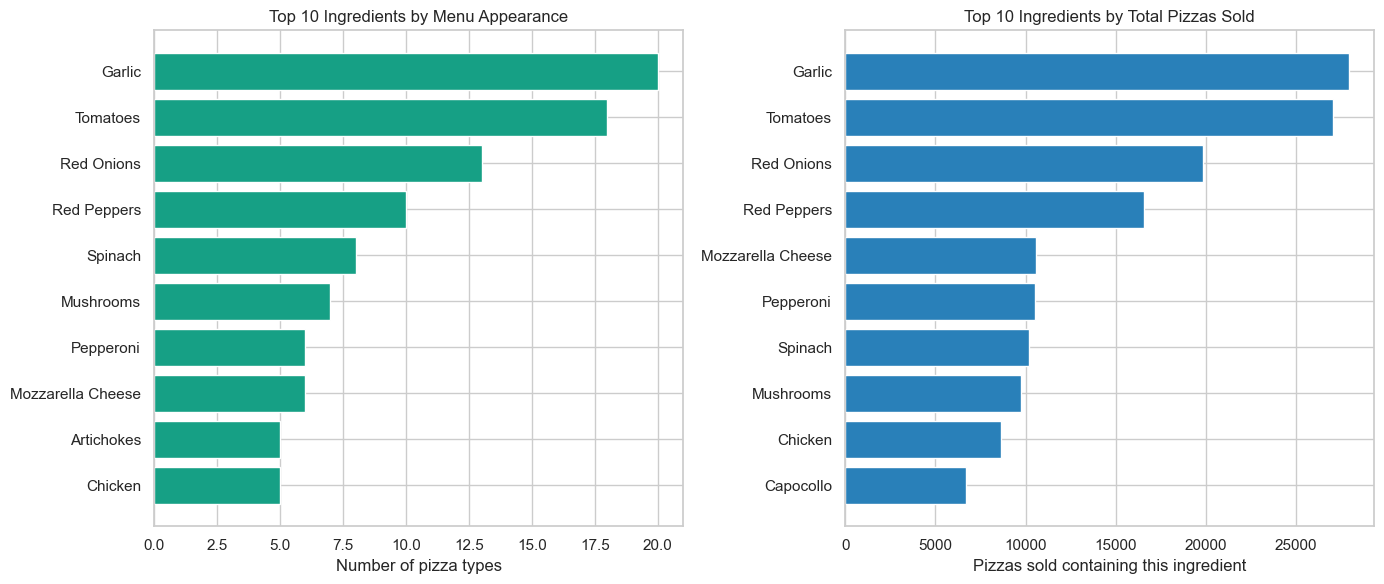

Top 10 by menu appearance:
Garlic               20
Tomatoes             18
Red Onions           13
Red Peppers          10
Spinach               8
Mushrooms             7
Pepperoni             6
Mozzarella Cheese     6
Artichokes            5
Chicken               5
dtype: int64

Top 10 by total demand:
Garlic               27913
Tomatoes             27052
Red Onions           19834
Red Peppers          16562
Mozzarella Cheese    10569
Pepperoni            10540
Spinach              10166
Mushrooms             9729
Chicken               8618
Capocollo             6692
dtype: int64


In [26]:
from collections import Counter

# --- Menu-level frequency: how many pizza TYPES contain each ingredient ---
menu_ing_counter = Counter()
for ing_str in pizza_types['ingredients']:
    ings = [i.strip() for i in ing_str.split(',')]
    menu_ing_counter.update(ings)
menu_ing = pd.Series(menu_ing_counter).sort_values(ascending=False).head(10)

# --- Demand-weighted frequency: total pizzas SOLD containing each ingredient ---
pt_ingredients = pizza_types.set_index('pizza_type_id')['ingredients'].apply(
    lambda s: [i.strip() for i in s.split(',')])
qty_by_type = sales.groupby('pizza_type_id')['quantity'].sum()

demand_ing_counter = Counter()
for pt_id, qty in qty_by_type.items():
    for ing in pt_ingredients.get(pt_id, []):
        demand_ing_counter[ing] += qty
demand_ing = pd.Series(demand_ing_counter).sort_values(ascending=False).head(10)

# --- Plot side by side ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.barh(menu_ing.index[::-1], menu_ing.values[::-1], color='#16a085')
plt.title('Top 10 Ingredients by Menu Appearance')
plt.xlabel('Number of pizza types')

plt.subplot(1, 2, 2)
plt.barh(demand_ing.index[::-1], demand_ing.values[::-1], color='#2980b9')
plt.title('Top 10 Ingredients by Total Pizzas Sold')
plt.xlabel('Pizzas sold containing this ingredient')

plt.tight_layout()
plt.savefig(r"C:\Users\Adorejoy\COHORT 7 NOTEBOOK\pizza_sales\top_ingredients.png", dpi=300, bbox_inches="tight")
plt.show()

print("Top 10 by menu appearance:")
print(menu_ing)
print("\nTop 10 by total demand:")
print(demand_ing)

**Insights**

- **Garlic (20 types), Tomatoes (18), and Red Onions (13)** are the most common ingredients across the menu, and the same three top the demand-weighted ranking (27,913 / 27,052 / 19,834 pizzas sold) what's common on the menu is also what customers actually order.
- With 65 distinct ingredients averaging **5.66 per pizza**, the menu is clearly built around a reused "core" set rather than unique ingredient lists per pizza efficient for inventory and prep.
- Garlic spans all four categories, making it (along with tomatoes) **a critical inventory item** running out would affect nearly the whole menu, not just one style.

In [27]:
# Save merged dataframe
sales.to_csv(data_dir / "pizza_sales_merged.csv", index=False)